**Imports**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import os

from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, f1_score
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

import tensorflow as tf

# ── Full reproducibility seed block ─────────────────────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED']       = str(SEED)  # Python hash randomisation
os.environ['TF_DETERMINISTIC_OPS']  = '1'        # Forces deterministic CPU ops
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'       # Forces deterministic GPU/cuDNN
random.seed(SEED)                                # Python built-in random
np.random.seed(SEED)                             # NumPy
tf.random.set_seed(SEED)                         # TensorFlow / Keras
# ────────────────────────────────────────────────────────────────────────────

print('All imports & seeds set ✓')

All imports & seeds set ✓


**Load**

In [ ]:
df = pd.read_csv('EV_Charging_Load_Demand_Dataset.csv')
print('Original shape:', df.shape)

Original shape: (34020, 25)


**Sequence Function**

In [ ]:
def create_sequences(X, y, window=5):
    X_seq, y_seq = [], []
    for i in range(len(X) - window):
        X_seq.append(X[i:i+window])
        y_seq.append(y[i+window])
    return np.array(X_seq), np.array(y_seq)

**GRU Model**

In [ ]:
def build_gru_model(input_shape, seed=42):
    """Build GRU model. Re-seeding here ensures identical weight init
    every time the function is called, making results reproducible."""
    # Re-seed before every model build so weight initialisation is identical
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    model = Sequential([
        Input(shape=input_shape),

        GRU(64, return_sequences=True),
        Dropout(0.2),

        GRU(32),
        Dropout(0.2),

        Dense(16, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

**K-Fold Setup**

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

WINDOW = 5

**Storage**

In [ ]:
mae_list, mse_list, rmse_list, r2_list = [], [], [], []
mape_list, acc_list = [], []

f1_weighted_list = []
f1_low_list, f1_med_list, f1_high_list, f1_peak_list = [], [], [], []

all_actual = []
all_pred = []

**Training Loop (GRU)**

In [ ]:
y = df.iloc[:, -1]
X = df.iloc[:, :-1]

# Drop non-numeric
X = X.drop('vehicle_id', axis=1, errors='ignore')

non_numeric_cols = X.select_dtypes(include=['object']).columns
if not non_numeric_cols.empty:
    print(f"Dropping non-numeric columns: {list(non_numeric_cols)}")
    X = X.drop(columns=non_numeric_cols)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):
    print(f"\n===== Fold {fold} =====")

    # Split
    X_train_raw, X_test_raw = X.iloc[train_idx], X.iloc[test_idx]
    y_train_raw, y_test_raw = y.iloc[train_idx], y.iloc[test_idx]

    # Scaling (NO leakage)
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_train_scaled = scaler_X.fit_transform(X_train_raw)
    X_test_scaled  = scaler_X.transform(X_test_raw)

    y_train_scaled = scaler_y.fit_transform(y_train_raw.values.reshape(-1,1))
    y_test_scaled  = scaler_y.transform(y_test_raw.values.reshape(-1,1))

    # Sequence
    X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, WINDOW)
    X_test_seq, y_test_seq   = create_sequences(X_test_scaled, y_test_scaled, WINDOW)

    # Skip small folds (important fix)
    if len(X_test_seq) == 0 or len(X_train_seq) == 0:
        print("Skipping fold due to insufficient sequence length")
        continue

    # Model
    # Re-seed before each fold so weight init is deterministic
    model = build_gru_model((X_train_seq.shape[1], X_train_seq.shape[2]), seed=SEED)

    model.fit(
        X_train_seq, y_train_seq,
        # Fixed manual validation split (validation_split shuffles non-deterministically)
        validation_data=(X_train_seq[-int(len(X_train_seq)*0.2):],
                          y_train_seq[-int(len(y_train_seq)*0.2):]),
        epochs=100,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    # Predict
    y_pred_scaled = model.predict(X_test_seq).squeeze()

    # Inverse scale
    y_test_inv = scaler_y.inverse_transform(y_test_seq.reshape(-1,1)).squeeze()
    y_pred_inv = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).squeeze()

    # ===== REGRESSION =====
    mae = mean_absolute_error(y_test_inv, y_pred_inv)
    mse = mean_squared_error(y_test_inv, y_pred_inv)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_inv, y_pred_inv)

    mask = y_test_inv > 1e-3
    mape = np.mean(np.abs((y_test_inv[mask] - y_pred_inv[mask]) / y_test_inv[mask])) * 100
    acc = 100 - mape

    # ===== CLASSIFICATION =====
    bins = np.percentile(y_test_inv, [0, 25, 50, 75, 100])

    y_test_cls = np.digitize(y_test_inv, bins[1:-1])
    y_pred_cls = np.digitize(y_pred_inv, bins[1:-1])

    f1_w = f1_score(y_test_cls, y_pred_cls, average='weighted')
    f1_pc = f1_score(y_test_cls, y_pred_cls, average=None)

    f1_low, f1_med, f1_high, f1_peak = (list(f1_pc) + [0]*4)[:4]

    # Store
    mae_list.append(mae)
    mse_list.append(mse)
    rmse_list.append(rmse)
    r2_list.append(r2)

    mape_list.append(mape)
    acc_list.append(acc)

    f1_weighted_list.append(f1_w)
    f1_low_list.append(f1_low)
    f1_med_list.append(f1_med)
    f1_high_list.append(f1_high)
    f1_peak_list.append(f1_peak)

    all_actual.extend(y_test_inv)
    all_pred.extend(y_pred_inv)

Dropping non-numeric columns: ['lane_id', 'status', 'current_station_id']
Shape of X: (34020, 20)
Shape of y: (34020,)

===== Fold 1 =====
213/213 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

===== Fold 2 =====
213/213 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

===== Fold 3 =====
213/213 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

===== Fold 4 =====
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

===== Fold 5 =====
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


**Final Results**

In [ ]:
gru_kfold_row = {
    "Model": "GRU (KFold)",

    "MAE": np.mean(mae_list),
    "MSE": np.mean(mse_list),
    "RMSE": np.mean(rmse_list),
    "R2": np.mean(r2_list),

    "MAPE (%)": np.mean(mape_list),
    "Accuracy (%)": np.mean(acc_list),

    "F1 (weighted)": np.mean(f1_weighted_list),
    "F1_Low": np.mean(f1_low_list),
    "F1_Medium": np.mean(f1_med_list),
    "F1_High": np.mean(f1_high_list),
    "F1_Peak": np.mean(f1_peak_list)
}

gru_kfold_row

{'Model': 'GRU (KFold)',
 'MAE': np.float64(81.45079087977822),
 'MSE': np.float64(8028.41777598997),
 'RMSE': np.float64(89.49480535629421),
 'R2': np.float64(0.9444290654594203),
 'MAPE (%)': np.float64(9.237127304041023),
 'Accuracy (%)': np.float64(90.76287269595898),
 'F1 (weighted)': np.float64(0.5722925048307272),
 'F1_Low': np.float64(0.9073006646097556),
 'F1_Medium': np.float64(0.7954407452321747),
 'F1_High': np.float64(0.5333235031292729),
 'F1_Peak': np.float64(0.10934332610893507)}

**Append to Summary**

In [ ]:
if 'cls_df' not in globals():
    cls_df = pd.DataFrame([gru_kfold_row])
else:
    cls_df = pd.concat(
        [cls_df, pd.DataFrame([gru_kfold_row])],
        ignore_index=True
    )

**Print Table**

In [ ]:
print('=' * 75)
print('  CLASSIFICATION METRICS — Accuracy (MAPE-based) & F1-Score   (5-Fold CV)')
print('=' * 75)

for _, r in cls_df.iterrows():
    print(f"{r['Model']:<22} {r['Accuracy (%)']:>10.4f} {r['F1 (weighted)']:>9.4f}")

  CLASSIFICATION METRICS — Accuracy (MAPE-based) & F1-Score   (5-Fold CV)
GRU (KFold)               90.7629    0.5723


**Scatter Plot**

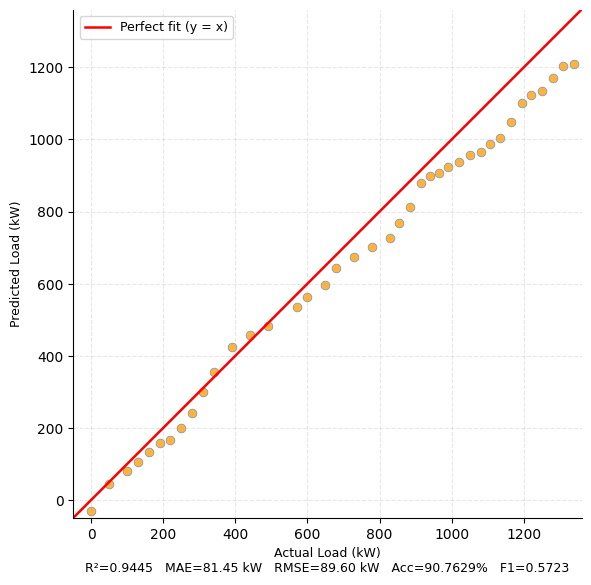

Saved → scatter_gru.png


In [ ]:
# ── Scatter Plot — GRU ───────────────────────────────────────────────────────
import pandas as pd

name  = 'GRU'
color = '#FF9800'

y_true = np.array(all_actual)
y_pred = np.array(all_pred)

# Metrics on original predictions (unchanged)
r2   = r2_score(y_true, y_pred)
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
acc  = np.mean(acc_list)
f1   = np.mean(f1_weighted_list)

# --- Aggregate to one point per unique actual value (mean predicted) ---
agg = pd.DataFrame({'actual': y_true, 'predicted': y_pred})
agg = agg.groupby('actual', as_index=False)['predicted'].mean()
y_agg  = agg['actual'].values
yp_agg = agg['predicted'].values

lims = [min(y_agg.min(), yp_agg.min()) - 20,
        max(y_agg.max(), yp_agg.max()) + 20]

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_agg, yp_agg,
           color=color, alpha=0.75, s=40,
           edgecolors='steelblue', linewidths=0.5)
ax.plot(lims, lims, 'r-', linewidth=1.8, label='Perfect fit (y = x)')
# ax.set_title(f'Actual vs Predicted — {name}',
#              fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel(
    f'Actual Load (kW)\n'
    f'R²={r2:.4f}   MAE={mae:.2f} kW   RMSE={rmse:.2f} kW   '
    f'Acc={acc:.4f}%   F1={f1:.4f}',
    fontsize=9)
ax.set_ylabel('Predicted Load (kW)', fontsize=9)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_aspect('equal')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('scatter_gru.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved → scatter_gru.png')